# Лабораторная работа 1. Подготовка данных

Датасет `russian_demography.csv`: 85 регионов России, 1990–2017 годы, 2380 строк.

- "year" - year (1990-2017)
- "region" - name of a federal subject of Russia. It could be oblast, republic, krai, autonomous okrug, federal city and a single autonomous oblast
- "npg" - natural population growth by 1000 people. Calculating as the difference between birth rate and death rate
- "birth_rate" - number of births by 1000 people
- "death_rate" - number of deaths by 1000 people
- "gdw" - general demographic weight (how many people of non-woking age account for 100 people of working age). Working age for men 16-60 years, for women 16-55 years
- "urbanization" - % of urban population

## 1. Загрузка и разведочный анализ

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import CubicSpline

plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.4})


In [5]:
df = pd.read_csv('russian_demography.csv')
print(df.shape)

df.head(10)
df.info()
df.isna().sum()
df['region'].nunique()
df.groupby('region').size()

(2380, 7)
<class 'pandas.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          2380 non-null   int64  
 1   region        2380 non-null   str    
 2   npg           2317 non-null   float64
 3   birth_rate    2317 non-null   float64
 4   death_rate    2315 non-null   float64
 5   gdw           2330 non-null   float64
 6   urbanization  2330 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 130.3 KB


region
Altai Krai                        28
Altai Republic                    28
Amur Oblast                       28
Arkhangelsk Oblast                28
Astrakhan Oblast                  28
                                  ..
Vologda Oblast                    28
Voronezh Oblast                   28
Yamalo-Nenets Autonomous Okrug    28
Yaroslavl Oblast                  28
Zabaykalsky Krai                  28
Length: 85, dtype: int64

### Опредление источников пропусков

In [6]:
na_by_region = df.groupby('region')['birth_rate'].apply(lambda s: s.isna().sum())
print(na_by_region[na_by_region > 0])

region
Chechen Republic          10
Republic of Crimea        24
Republic of Ingushetia     5
Sevastopol                24
Name: birth_rate, dtype: int64


In [7]:
perm = df[df['region'] == 'Perm Krai'].sort_values('year').reset_index(drop=True)

print(len(perm))
print(sorted(df['region'].unique()))

28
['Altai Krai', 'Altai Republic', 'Amur Oblast', 'Arkhangelsk Oblast', 'Astrakhan Oblast', 'Belgorod Oblast', 'Bryansk Oblast', 'Chechen Republic', 'Chelyabinsk Oblast', 'Chukotka Autonomous Okrug', 'Chuvash Republic', 'Irkutsk Oblast', 'Ivanovo Oblast', 'Jewish Autonomous Oblast', 'Kabardino-Balkar Republic', 'Kaliningrad Oblast', 'Kaluga Oblast', 'Kamchatka Krai', 'Karachay-Cherkess Republic', 'Kemerovo Oblast', 'Khabarovsk Krai', 'Khanty–Mansi Autonomous Okrug – Yugra', 'Kirov Oblast', 'Komi Republic', 'Kostroma Oblast', 'Krasnodar Krai', 'Krasnoyarsk Krai', 'Kurgan Oblast', 'Kursk Oblast', 'Leningrad Oblast', 'Lipetsk Oblast', 'Magadan Oblast', 'Mari El Republic', 'Moscow', 'Moscow Oblast', 'Murmansk Oblast', 'Nenets Autonomous Okrug', 'Nizhny Novgorod Oblast', 'Novgorod Oblast', 'Novosibirsk Oblast', 'Omsk Oblast', 'Orenburg Oblast', 'Oryol Oblast', 'Penza Oblast', 'Perm Krai', 'Primorsky Krai', 'Pskov Oblast', 'Republic of Adygea', 'Republic of Bashkortostan', 'Republic of Bury

### Добавление катигориальной переменной

In [16]:
OKRUGA = {
    'Центральный': [
        'Belgorod Oblast', 'Bryansk Oblast', 'Vladimir Oblast', 'Voronezh Oblast',
        'Ivanovo Oblast', 'Kaluga Oblast', 'Kostroma Oblast', 'Kursk Oblast',
        'Lipetsk Oblast', 'Moscow', 'Moscow Oblast', 'Oryol Oblast', 'Ryazan Oblast',
        'Smolensk Oblast', 'Tambov Oblast', 'Tver Oblast', 'Tula Oblast', 'Yaroslavl Oblast',
    ],
    'Северо-Западный': [
        'Arkhangelsk Oblast', 'Vologda Oblast', 'Kaliningrad Oblast', 'Komi Republic',
        'Leningrad Oblast', 'Murmansk Oblast', 'Nenets Autonomous Okrug', 'Novgorod Oblast',
        'Pskov Oblast', 'Republic of Karelia', 'Saint Petersburg',
    ],
    'Южный': [
        'Republic of Adygea', 'Astrakhan Oblast', 'Volgograd Oblast', 'Republic of Kalmykia',
        'Krasnodar Krai', 'Rostov Oblast', 'Republic of Crimea', 'Sevastopol',
    ],
    'Северо-Кавказский': [
        'Republic of Dagestan', 'Republic of Ingushetia', 'Kabardino-Balkar Republic',
        'Karachay-Cherkess Republic', 'Republic of North Ossetia-Alania',
        'Chechen Republic', 'Stavropol Krai',
    ],
    'Приволжский': [
        'Republic of Bashkortostan', 'Mari El Republic', 'Republic of Mordovia',
        'Republic of Tatarstan', 'Udmurt Republic', 'Chuvash Republic', 'Perm Krai',
        'Kirov Oblast', 'Nizhny Novgorod Oblast', 'Orenburg Oblast', 'Penza Oblast',
        'Samara Oblast', 'Saratov Oblast', 'Ulyanovsk Oblast',
    ],
    'Уральский': [
        'Kurgan Oblast', 'Sverdlovsk Oblast', 'Tyumen Oblast', 'Chelyabinsk Oblast',
        'Khanty–Mansi Autonomous Okrug – Yugra', 'Yamalo-Nenets Autonomous Okrug',
    ],
    'Сибирский': [
        'Altai Republic', 'Altai Krai', 'Republic of Buryatia', 'Zabaykalsky Krai',
        'Irkutsk Oblast', 'Kemerovo Oblast', 'Krasnoyarsk Krai', 'Novosibirsk Oblast',
        'Omsk Oblast', 'Tomsk Oblast', 'Tuva Republic', 'Republic of Khakassia',
    ],
    'Дальневосточный': [
        'Sakha (Yakutia) Republic', 'Kamchatka Krai', 'Primorsky Krai', 'Khabarovsk Krai',
        'Amur Oblast', 'Magadan Oblast', 'Sakhalin Oblast', 'Jewish Autonomous Oblast',
        'Chukotka Autonomous Okrug',
    ],
}

fd = {region: okrug for okrug, regions in OKRUGA.items() for region in regions}


## 2. Построение диаграмм

### 2.1. Линейная

Строим динамику рождаемости и смертности за 1990–2017. Серым показаны 85 региональных рядов (2380 значений), жирными линиями - средние по стране.

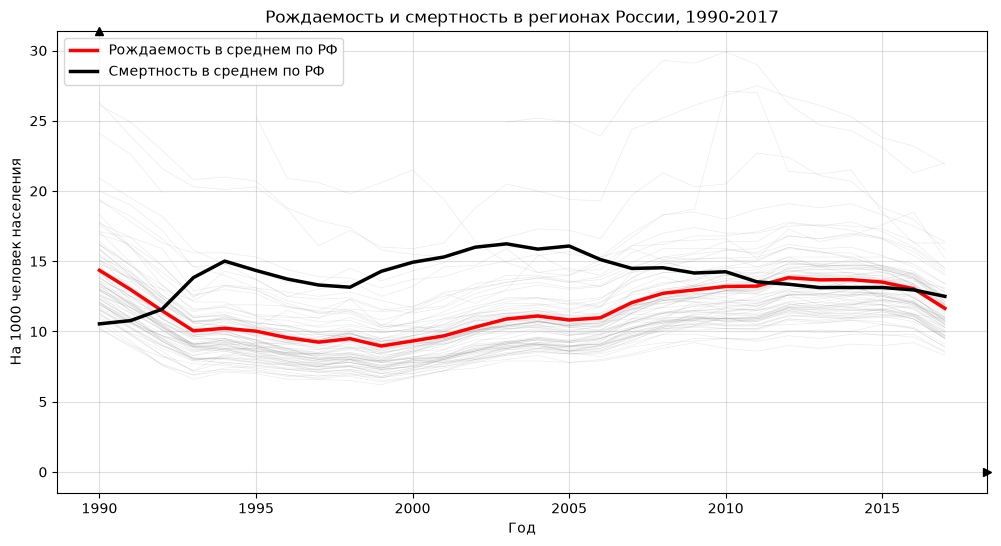

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
pivot = df.pivot(index='year', columns='region', values='birth_rate')
ax.plot(pivot.index, pivot.values, color='gray', alpha=0.15, linewidth=0.5)

mean_birth = df.groupby('year')['birth_rate'].mean()
ax.plot(mean_birth.index, mean_birth.values, color= 'red', linewidth=2.5, label= 'Рождаемость в среднем по РФ')
mean_death = df.groupby('year')['death_rate'].mean()
ax.plot(mean_death.index, mean_death.values, color= 'black', linewidth=2.5, label= 'Смертность в среднем по РФ')

ax.set_xlabel('Год')
ax.set_ylabel('На 1000 человек населения')
ax.set_title('Рождаемость и смертность в регионах России, 1990-2017')
ax.legend()

ax.plot(1, 0, '>k', transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(pivot.index.min(), 1, '^k', transform=ax.get_xaxis_transform(), clip_on=False)


### Интерпретация

«Русский крест». В 1992 году кривые рождаемости и смертности пересекаются: смертность впервые превышает рождаемость, естественный прирост становится отрицательным. Явление получило название «русский крест» по характерной форме графика. Причины - экономический шок переходного периода, падение уровня жизни, откладывание рождений.

1990-1994, обвал. Рождаемость падает примерно с 13 до 9 на 1000 человек, смертность растёт с 11 до 16. Разрыв достигает максимума.

1994-2005, плато депопуляции. Рождаемость стабилизируется на низком уровне, смертность держится около 15–16 с пиком в начале 2000-х. Естественная убыль сохраняется более десяти лет.

2007-2015, восстановление. С 2007 года рождаемость устойчиво растёт. Совпадает с введением материнского капитала (федеральная программа с 1 января 2007). К 2013 году кривые снова сближаются, естественный прирост ненадолго выходит в плюс.

2016–2017, новый спад. Рождаемость снова падает. Основная причина - демографическое эхо: в репродуктивный возраст входит малочисленное поколение, рождённое в 1990-е.

### 2.2. Столбчатая

Строим две столбчатые диаграммы. Первая показывает весь массив - 2380 значений, каждое отдельной вертикальной линией. Вторая - топ-15 регионов по рождаемости в 2017 году.

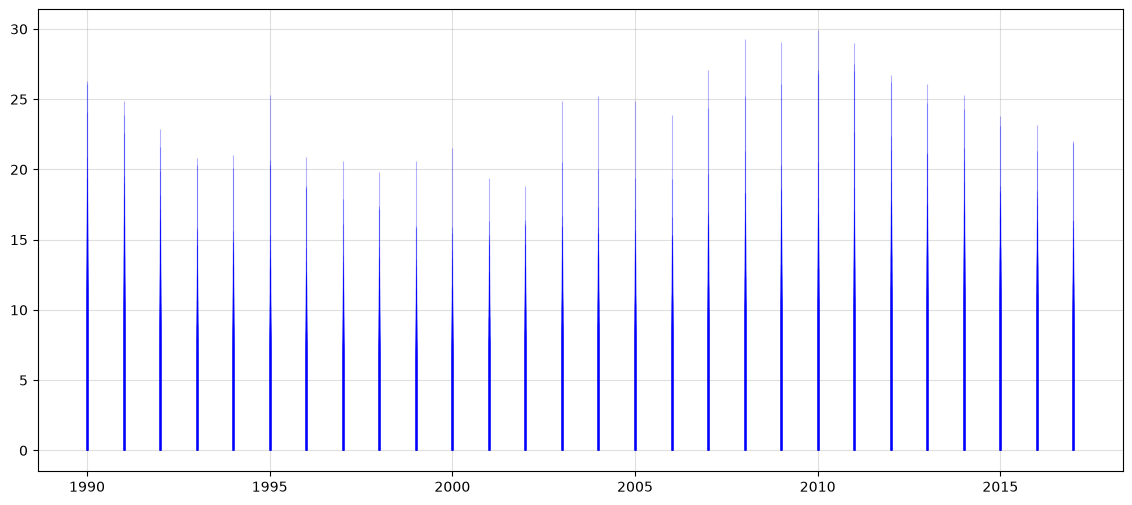

In [10]:
fig, ax = plt.subplots(figsize= (14,6))
ax.vlines(df['year'], 0, df['birth_rate'], color='blue', alpha=0.3, linewidth=0.8)

Каждый год представлен пучком из 85 линий, по одной на регион. Из-за наложения читается в основном верхняя граница - максимальная рождаемость по стране в этом году. Видно, что максимум держался около 20-21 в конце 1990-х и вырос до 29-30 к 2010-2011. Это не средняя по стране: сверху всегда одни и те же регионы, Чечня и Тыва. Средняя динамика видна на линейной диаграмме выше.

Чтобы диаграмма читалась, берём срез по последнему году и 15 регионов с наибольшей рождаемостью. Пунктиром отмечено среднее по России.

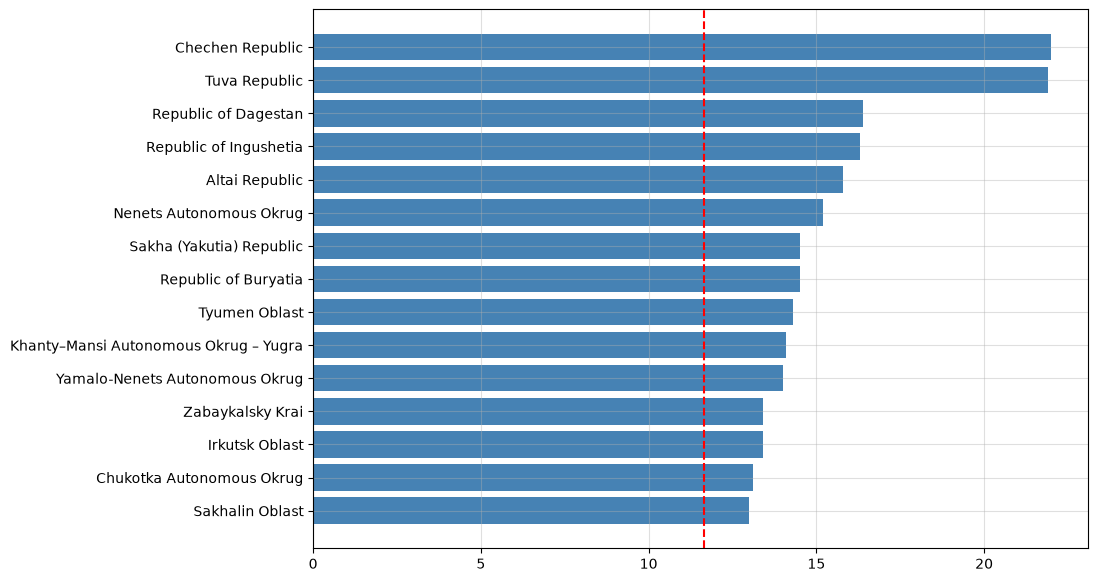

In [11]:
top15 = (df[df['year'] == 2017].nlargest(15, 'birth_rate').sort_values('birth_rate'))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15['region'], top15['birth_rate'], color='steelblue')
ax.axvline(df[df['year'] == 2017]['birth_rate'].mean(), color= 'red', linestyle = '--', label='Среднее по РФ')

Первые места держат республики Кавказа и Тыва. Северные нефтегазовые округа попадают в топ по другой причине: население там молодое из-за трудовой миграции.

### 2.3. Круговая

Распределяем регионы по доле городского населения в 2017 году. Границы корзин: до 50%, 50-70%, 70-85%, больше 85%.

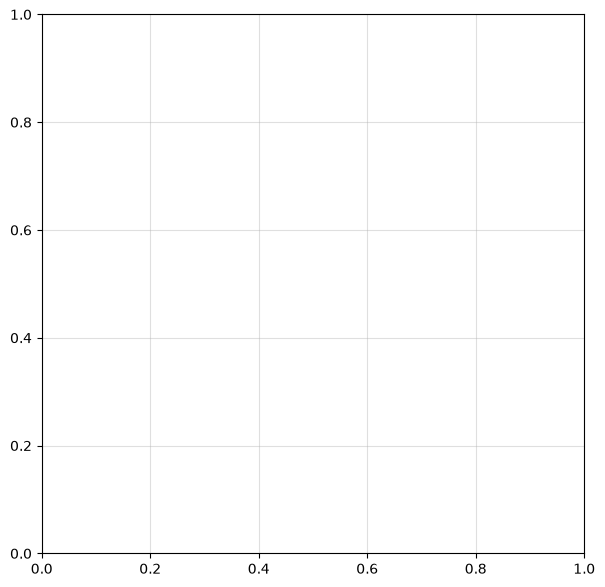

In [17]:
d2017 = df[df['year'] == 2017]
bins = pd.cut(d2017['urbanization'], bins=[0,50,70,85,100], labels=['< 50%', '50–70%', '70–85%', '> 85%'])
counts = bins.value_counts().sort_index()

fig, ax = plt.subplots(figsize = (7, 7))


Больше 80% регионов попадают в средние группы, 50-85% городского населения. Крайние группы маленькие и одинаковые по размеру - по 7 регионов.

Разброс от 29.2% до 100%. Сто процентов - это города федерального значения, там сельского населения нет. На другом конце Алтай, Дагестан, Чечня.

Группы с низкой урбанизацией пересекаются с лидерами предыдущей диаграммы. Связь ожидаемая: в сельской местности рожают больше, чем в городах.

### 2.4. Скрипичная

In [14]:
order = df.groupby('fd')['birth_rate'].median().sort_values().index

fig, ax = plt.subplots(figsize=(13, 6))
sns.violinplot(data=df, x='fd', y='birth_rate', order=order, ax=ax)

ax.set_xlabel('Федеральный округ')
ax.set_ylabel('Число рождений на 1000 человек')
ax.set_title('Распределение рождаемости по федеральным округам, 1990–2017')

plt.xticks(rotation=45, ha='right');
plt.tight_layout()

KeyError: 'fd'

## 3. Качественный анализ

In [11]:
df[['npg', 'birth_rate', 'death_rate', 'gdw', 'urbanization']].corr().round(2)

,npg,birth_rate,death_rate,gdw,urbanization
npg,1.00,0.89,-0.91,-0.14,-0.32
birth_rate,0.89,1.00,-0.62,-0.09,-0.42
death_rate,-0.91,-0.62,1.00,0.16,0.17
gdw,-0.14,-0.09,0.16,1.00,-0.37
urbanization,-0.32,-0.42,0.17,-0.37,1.00


Данные - демография регионов России. Естественный прирост считается как рождаемость минус смертность, поэтому сильнее всего связан с ними: 0.89 и -0.91. Рождаемость и смертность связаны обратно (-0.62). Где рожают много, население моложе и умирает меньше.

Урбанизация связана с рождаемостью отрицательно (-0.42). В городах рожают меньше, поэтому в лидерах по рождаемости сельские республики Кавказа и Тыва, а на дне Центральный округ.

По времени главная зависимость - «русский крест» с линейной диаграммы: с 1992 года смертность выше рождаемости, после 2007 года рождаемость растёт, к 2017 году снова падает.

## 4. Методы заполнения пропусков

Берём рождаемость в Пермском крае, 28 значений. Оставляем каждое второе (чётные годы), остальные 14 удаляем и восстанавливаем.

In [12]:
x = perm['year'].values
y = perm['birth_rate'].values

known = np.arange(len(y)) % 2 == 0
x_known, y_known = x[known], y[known]
x_miss, y_miss = x[~known], y[~known]

res = pd.DataFrame({'year': x_miss, 'real': y_miss})
res['mean'] = y_known.mean()
res['median'] = np.median(y_known)

y_thin = pd.Series(np.where(known, y, np.nan))
res['prev3'] = [y_thin[:i].dropna().tail(3).mean() for i in np.where(~known)[0]]

Метод Лагранжа считаем по формуле интерполяционного многочлена.

In [13]:
def lagrange(xs, ys, t):
    L = 0
    for i in range(len(xs)):
        l = 1
        for j in range(len(xs)):
            if j != i:
                l *= (t - xs[j]) / (xs[i] - xs[j])
        L += ys[i] * l
    return L

res['lagrange'] = [lagrange(x_known, y_known, t) for t in x_miss]
res['spline'] = CubicSpline(x_known, y_known)(x_miss)
res.round(2)

,year,real,mean,median,prev3,lagrange,spline
0,1991,12.3,11.99,11.3,13.90,8.56,12.36
1,1993,9.8,11.99,11.3,12.55,11.17,10.37
2,1995,9.4,11.99,11.3,11.63,9.15,9.46
3,1997,9.2,11.99,11.3,10.13,9.78,9.62
4,1999,9.3,11.99,11.3,9.67,9.62,9.68
5,2001,10.2,11.99,11.3,9.63,10.25,10.26
6,2003,11.3,11.99,11.3,10.17,11.47,11.42
7,2005,10.9,11.99,11.3,10.70,11.04,11.03
8,2007,12.1,11.99,11.3,11.13,11.73,11.87
9,2009,13.3,11.99,11.3,11.80,14.00,13.69


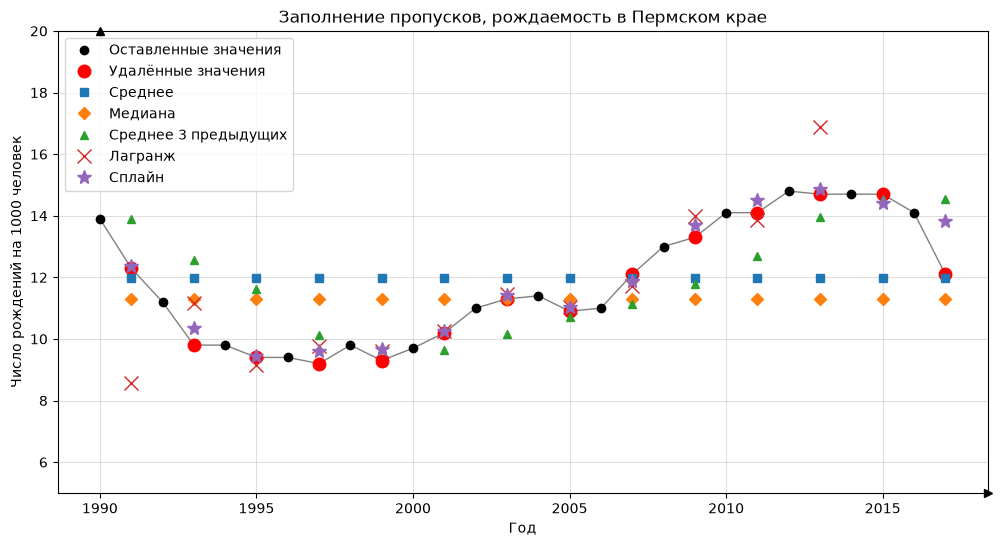

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, y, color='gray', linewidth=1)
ax.plot(x_known, y_known, 'o', color='black', label='Оставленные значения')
ax.plot(x_miss, y_miss, 'o', color='red', markersize=9, label='Удалённые значения')

ax.plot(res['year'], res['mean'], 's', label='Среднее')
ax.plot(res['year'], res['median'], 'D', label='Медиана')
ax.plot(res['year'], res['prev3'], '^', label='Среднее 3 предыдущих')
ax.plot(res['year'], res['lagrange'], 'x', markersize=10, label='Лагранж')
ax.plot(res['year'], res['spline'], '*', markersize=10, label='Сплайн')

ax.set_ylim(5, 20)
ax.set_xlabel('Год')
ax.set_ylabel('Число рождений на 1000 человек')
ax.set_title('Заполнение пропусков, рождаемость в Пермском крае')
ax.legend()

ax.plot(1, 5, '>k', transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(x.min(), 1, '^k', transform=ax.get_xaxis_transform(), clip_on=False)

Среднее (11.99) и медиана (11.3) ставят одно число на все пропуски и не видят ни провала 1990-х, ни роста после 2007 года.

Среднее трёх предыдущих повторяет форму ряда, но запаздывает: в 1991 году 13.9 вместо 12.3.

Лагранж внутри ряда работает, а на краях раскачивается: 2.3 в 2015 году и 263.7 в 2017-м, поэтому ось y обрезана.

Ближе всех сплайн. Внутри ряда ошибка меньше 0.6, заметно промахнулся только в 2017 году (13.8 вместо 12.1): это край ряда.

## 5. Анализ достоверности

Берём сплайн и проверяем разницу с реальными значениями правилом 2σ и 3σ.

In [15]:
res['diff'] = res['real'] - res['spline']
mu, sigma = res['diff'].mean(), res['diff'].std()
print('mu =', round(mu, 3), 'sigma =', round(sigma, 3))

res['out_2s'] = (res['diff'] - mu).abs() > 2 * sigma
res['out_3s'] = (res['diff'] - mu).abs() > 3 * sigma
res[['year', 'real', 'spline', 'diff', 'out_2s', 'out_3s']].round(2)

mu = -0.283 sigma = 0.48


,year,real,spline,diff,out_2s,out_3s
0,1991,12.3,12.36,-0.06,False,False
1,1993,9.8,10.37,-0.57,False,False
2,1995,9.4,9.46,-0.06,False,False
3,1997,9.2,9.62,-0.42,False,False
4,1999,9.3,9.68,-0.38,False,False
5,2001,10.2,10.26,-0.06,False,False
6,2003,11.3,11.42,-0.12,False,False
7,2005,10.9,11.03,-0.13,False,False
8,2007,12.1,11.87,0.23,False,False
9,2009,13.3,13.69,-0.39,False,False


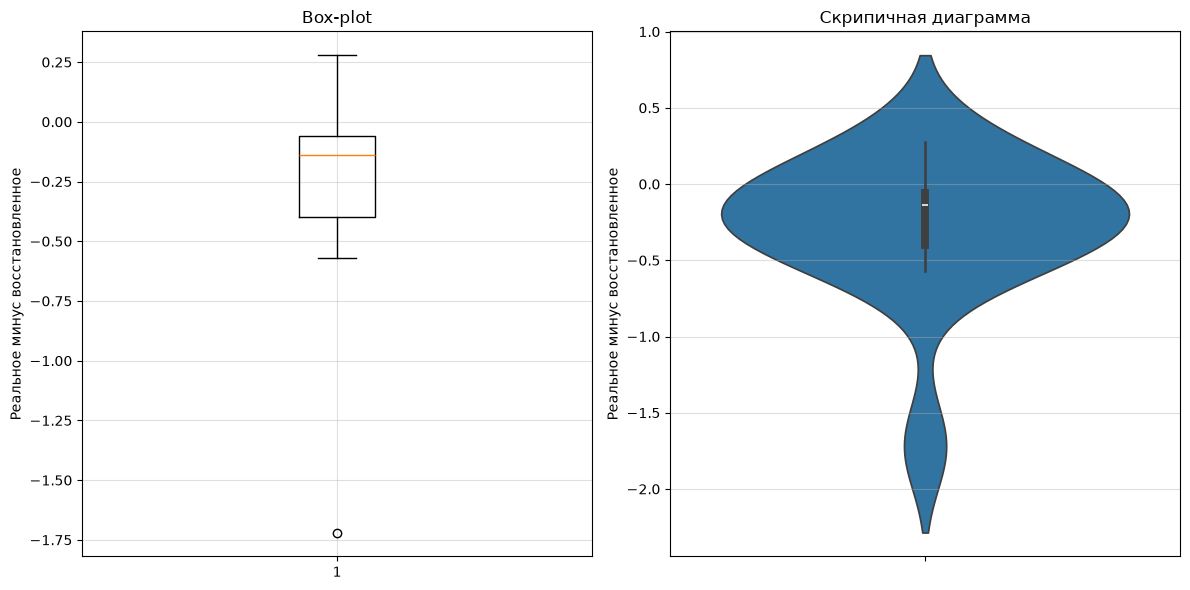

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].boxplot(res['diff'])
axes[0].set_title('Box-plot')
axes[0].set_ylabel('Реальное минус восстановленное')

sns.violinplot(y=res['diff'], ax=axes[1])
axes[1].set_title('Скрипичная диаграмма')
axes[1].set_ylabel('Реальное минус восстановленное')
plt.tight_layout()

По правилу 2σ недостоверное значение одно - 2017 год, разница -1.72. По 3σ выбросов нет. На box-plot 2017 год тоже отдельная точка за усом, остальные разницы в пределах ±0.6.

## 6. Дополнительная часть

Датасет выбран самостоятельно, не из папки преподавателя.

### 6.1. График с выделенными областями

Средняя рождаемость по регионам, закрашена полоса ± одно стандартное отклонение.

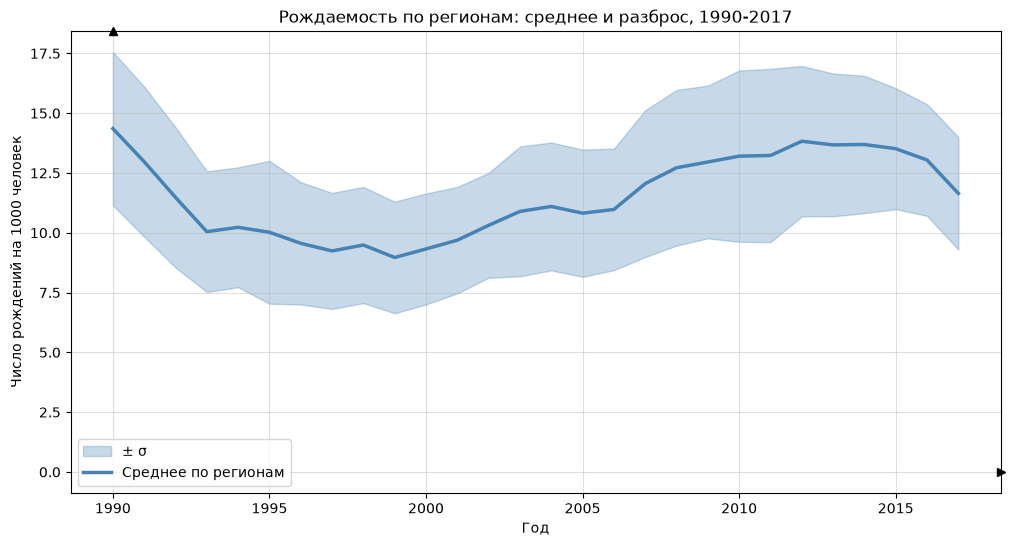

In [17]:
stats = df.groupby('year')['birth_rate'].agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(stats.index, stats['mean'] - stats['std'], stats['mean'] + stats['std'], color='steelblue', alpha=0.3, label='± σ')
ax.plot(stats.index, stats['mean'], color='steelblue', linewidth=2.5, label='Среднее по регионам')

ax.set_xlabel('Год')
ax.set_ylabel('Число рождений на 1000 человек')
ax.set_title('Рождаемость по регионам: среднее и разброс, 1990-2017')
ax.legend()

ax.plot(1, 0, '>k', transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(stats.index.min(), 1, '^k', transform=ax.get_xaxis_transform(), clip_on=False)

Средняя рождаемость падает с 14.35 в 1990 году до минимума 8.97 в 1999-м, к 2012 году растёт до 13.83 и к 2017-му опускается до 11.65. Полоса самая узкая в 2002 году (σ = 2.19) и самая широкая в 2011-м (σ = 3.62): в годы роста регионы расходились сильнее.

### 6.2. Искусственные пропуски и метрики

Имитируем сбой: удаляем 6 лет подряд, 2003-2008.

In [18]:
gap = (x >= 2003) & (x <= 2008)
x_ok, y_ok = x[~gap], y[~gap]

res_gap = pd.DataFrame({'year': x[gap], 'real': y[gap]})
res_gap['mean'] = y_ok.mean()
res_gap['median'] = np.median(y_ok)
res_gap['lagrange'] = [lagrange(x_ok, y_ok, t) for t in x[gap]]
res_gap['spline'] = CubicSpline(x_ok, y_ok)(x[gap])

def metrics(real, pred):
    mae = np.mean(np.abs(real - pred))
    rmse = np.sqrt(np.mean((real - pred) ** 2))
    mape = np.mean(np.abs(real - pred) / real) * 100
    mase = mae / np.mean(np.abs(np.diff(y)))
    return [mae, rmse, mape, mase]

pd.DataFrame({m: metrics(res_gap['real'], res_gap[m]) for m in ['mean', 'median', 'lagrange', 'spline']},
             index=['MAE', 'RMSE', 'MAPE', 'MASE']).T.round(3)

,MAE,RMSE,MAPE,MASE
mean,0.714,0.779,6.164,1.285
median,0.633,0.730,5.364,1.140
lagrange,108.485,126.082,954.922,195.272
spline,0.562,0.672,4.979,1.012


Лучший сплайн: MAE 0.56, MAPE 5%. Медиана близко (MAE 0.63), потому что в 2003-2008 рождаемость была около медианы ряда. Лагранж по 22 точкам улетает до 208, MAPE 955%.